In [86]:
import xarray as xr 
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.collections import LineCollection

In [87]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/cmohe30c_attributions_TP.nc')
ds['fields'] = ds.attributions / ds.sensitivity

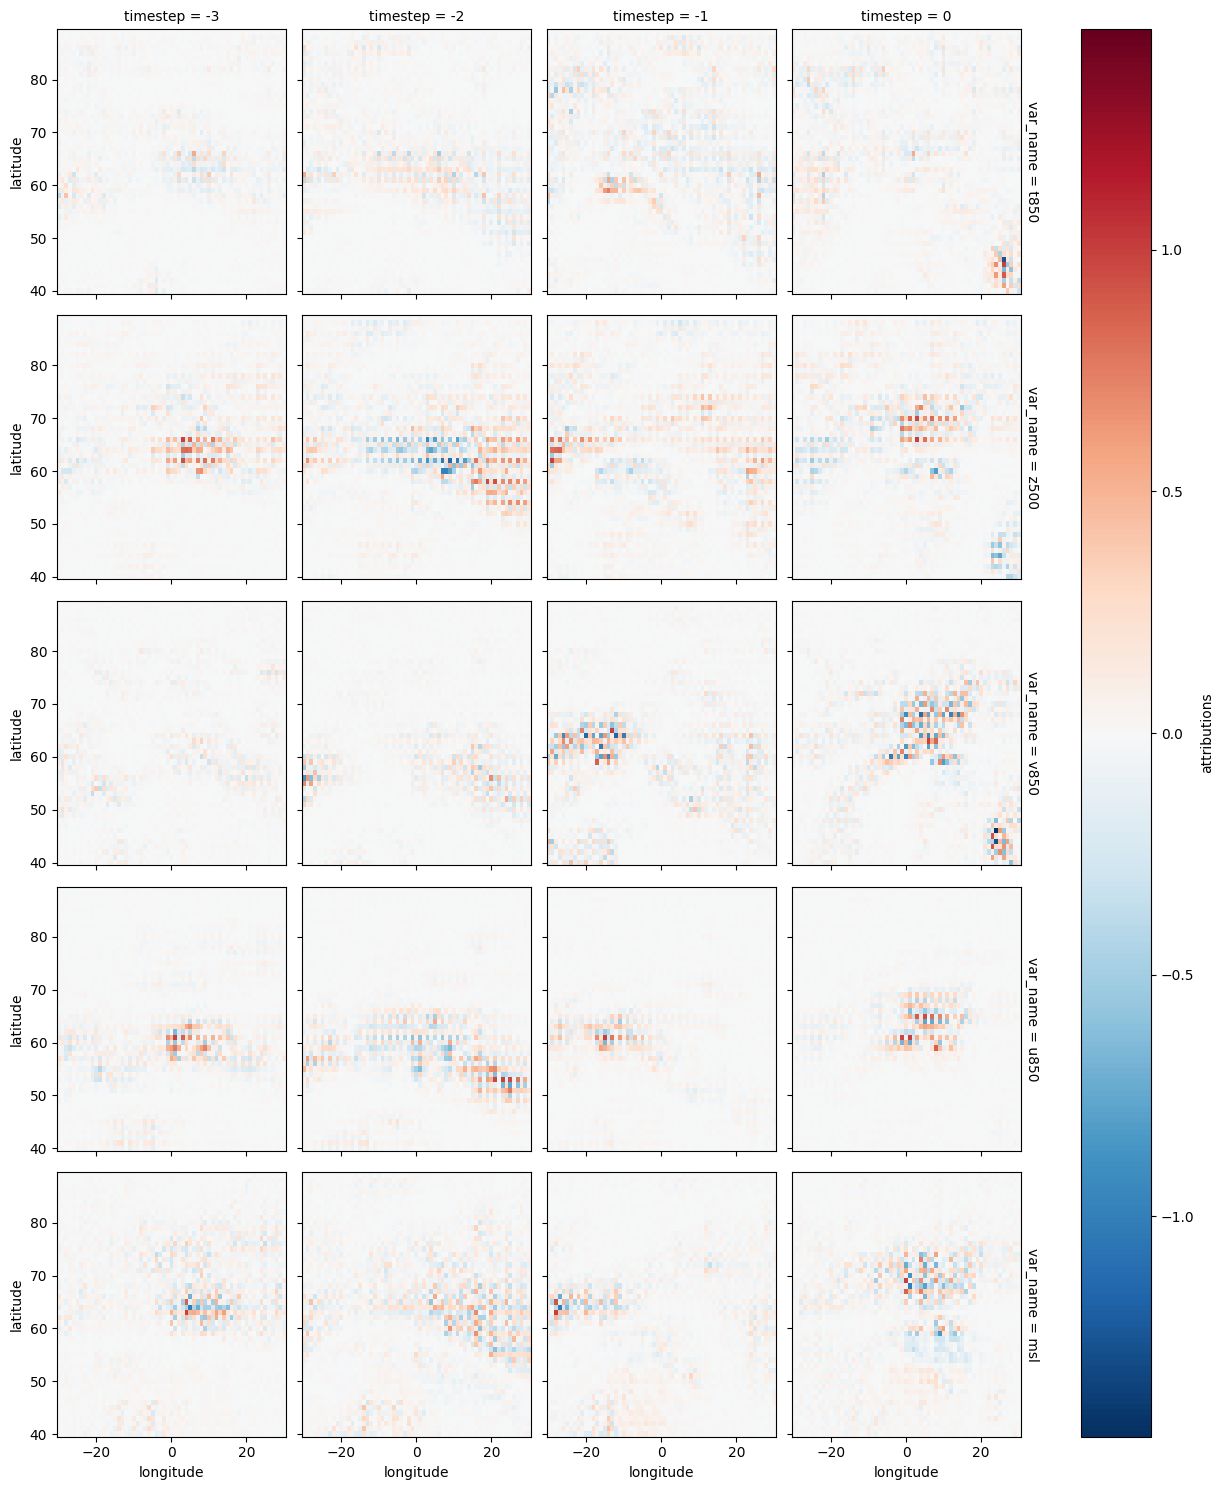

In [88]:
ds_extract = ds.sel(time='2008-01-28').attributions
(ds_extract/ds_extract.max(['longitude','latitude'])).sel(longitude=slice(-30,30), latitude=slice(40,None)).plot(row='var_name', col='timestep')

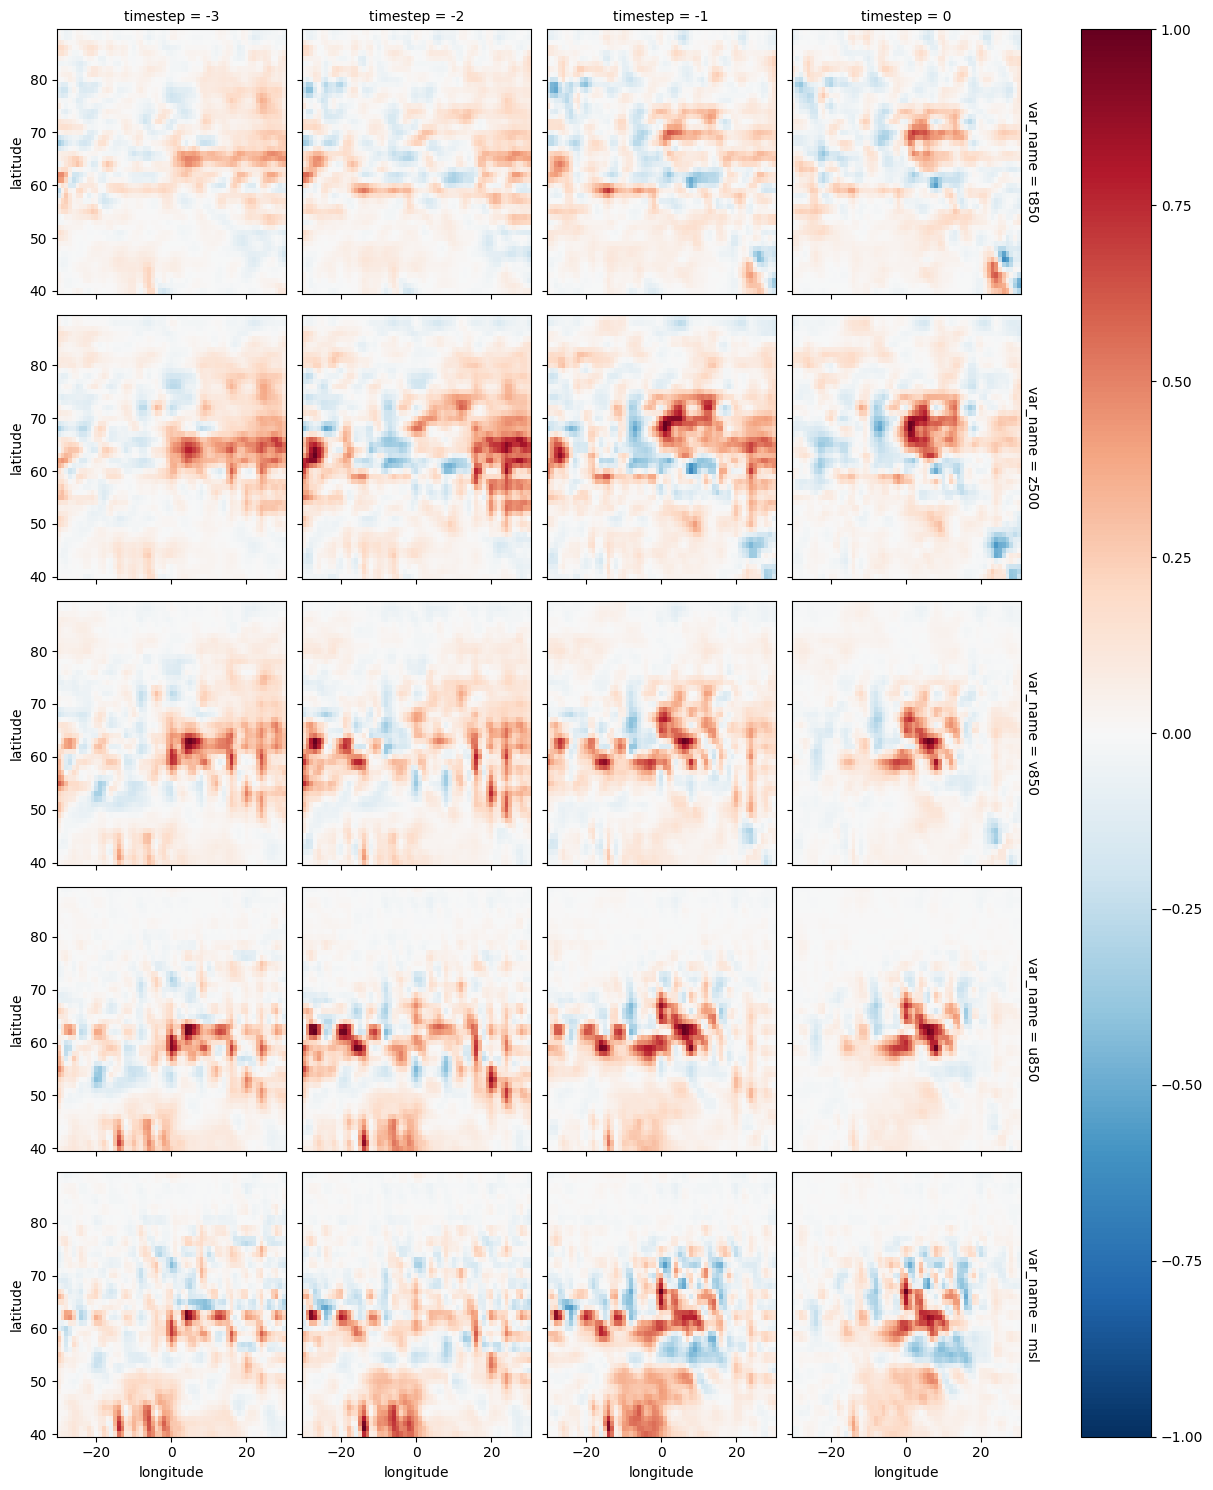

In [89]:
ds_extract = ds.sel(time='2008-01-28').attributions
from scipy.ndimage import gaussian_filter
smooth_ig = gaussian_filter(ds_extract, sigma=1.0)
ds_extract_smooth = xr.DataArray(smooth_ig, dims=ds_extract.dims, coords=ds_extract.coords)
(ds_extract_smooth/ds_extract_smooth.max(['longitude','latitude'])).sel(longitude=slice(-30,30), latitude=slice(40,None)).plot(row='var_name', col='timestep')

In [54]:
df_ = ds.fields.to_series().reset_index().pivot(columns = ['var_name'], values='fields', index = ['longitude','latitude','time','timestep'])


<Axes: xlabel='var_name', ylabel='var_name'>

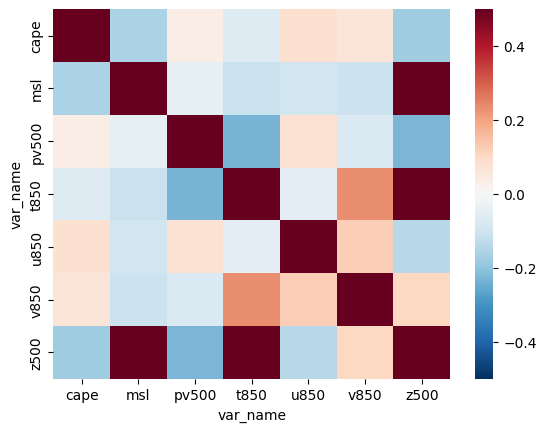

In [50]:
sns.heatmap(df_.corr(), vmin=-.5, vmax=.5, cmap='RdBu_r')

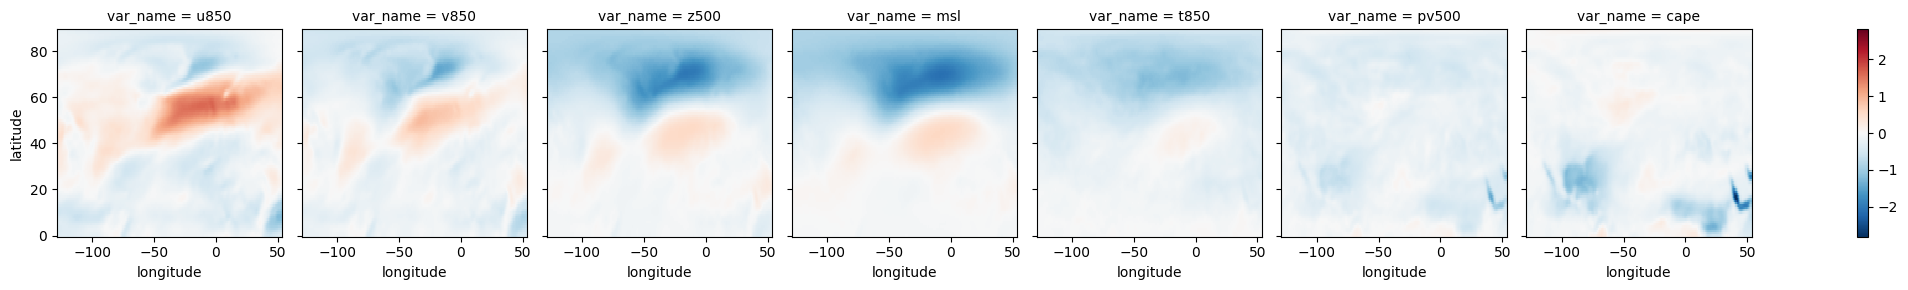

In [31]:
ds_3d = ds.sel(timestep=-3).fields
from scipy.ndimage import gaussian_filter
smooth_ig = gaussian_filter(ds_3d, sigma=1.0)
ds_3d_smooth = xr.DataArray(smooth_ig, dims=ds_3d.dims, coords=ds_3d.coords)
ds_3d_smooth.mean('time').plot(col='var_name')

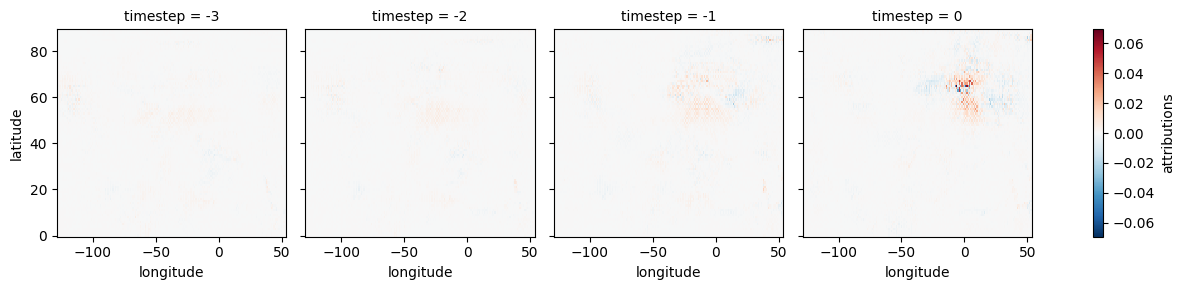

In [64]:
ds.sum([ 'var_name']).attributions.isel(time=0).plot(col='timestep')

AttributeError: Rectangle.set() got an unexpected keyword argument 'stacked'

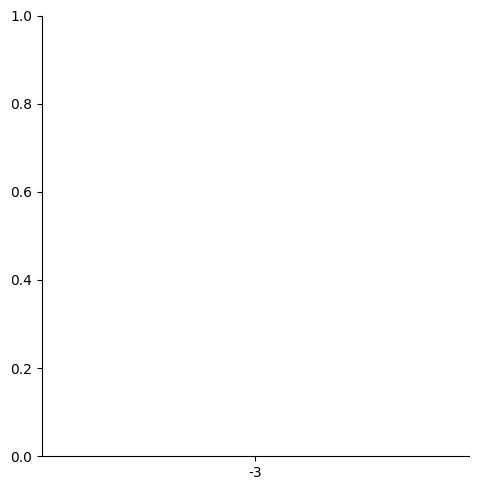

In [59]:
df_ = ds.sum(['longitude','latitude']).attributions.to_series().reset_index()
sns.catplot(df_, x='timestep',hue='var_name', y='attributions', dodge=True, kind='bar', stacked=True)
plt.grid()

In [77]:
all_features = xr.open_dataset("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr")
all_features

<xarray.Dataset> Size: 24GB
Dimensions:      (time: 31047, var_name: 3, latitude: 90, longitude: 360)
Coordinates:
  * var_name     (var_name) <U4 48B 'slp' 'u850' 'v850'
  * latitude     (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * time         (time) datetime64[ns] 248kB 1940-01-01 ... 2024-12-31
  * longitude    (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    data_normed  (time, var_name, latitude, longitude) float64 24GB ...
    mean_value   (var_name, latitude, longitude) float64 778kB ...
    std_value    (var_name) float64 24B ...

In [79]:
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/1z31zl1k_attributions_TP.nc')
ds_attrs_dropout = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/jedubddx_attributions_TP.nc')
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True).loc[ds_attrs.time]

ds_attrs['features'] = (ds_attrs.attributions/ds_attrs.sensitivity)*all_features.std_value +all_features.mean_value
ds_attrs_dropout['features'] =  (ds_attrs_dropout.attributions/ds_attrs_dropout.sensitivity)*all_features.std_value +all_features.mean_value


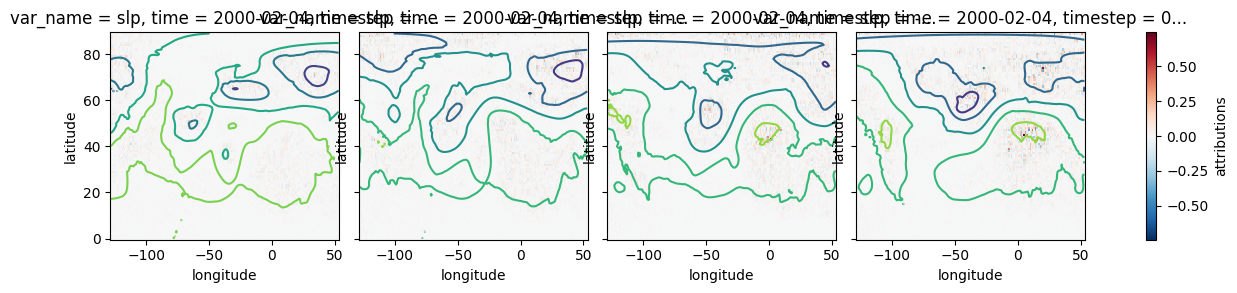

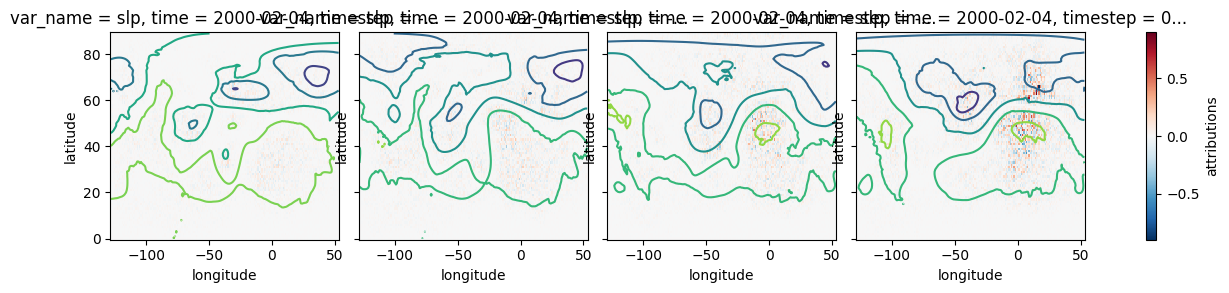

In [80]:
time = 10
common_times = ds_attrs.time.where(ds_attrs.time.isin(ds_attrs_dropout.time.values), drop=True)
plot = ds_attrs.attributions.sel(time=common_times).isel(time=time).plot(col='timestep')
for k,ax in enumerate(plot.axs.flatten()):
    ds_attrs.features.sel(time=common_times).isel(time=time).isel(timestep=k).squeeze().plot.contour(ax=ax,)
plot = ds_attrs_dropout.attributions.sel(time=common_times).isel(time=time).plot(col='timestep')
for k,ax in enumerate(plot.axs.flatten()):
    ds_attrs.features.sel(time=common_times).isel(time=time).isel(timestep=k).squeeze().plot.contour(ax=ax,)

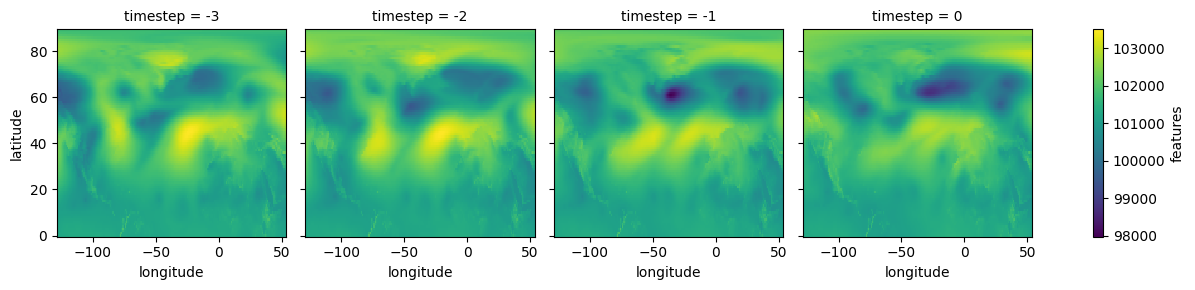

In [86]:
ds_attrs.features.isel(time=0).plot(col='timestep')

/tmp/ipykernel_467974/2912210259.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df_.groupby(pd.cut(df_.features, np.arange(94000,105000,300))).attributions.sum()
/tmp/ipykernel_467974/2912210259.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df_.groupby(pd.cut(df_.features, np.arange(94000,105000,300))).attributions.sum()


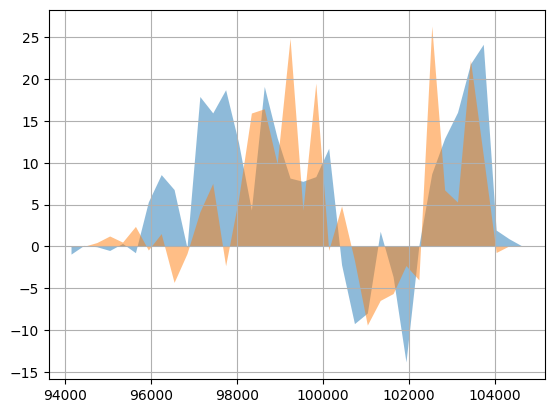

In [117]:
ds_test= ds_attrs.sel(time=common_times).isel(time=range(20))
df_ = ds_test.to_dataframe()
groups = df_.groupby(pd.cut(df_.features, np.arange(94000,105000,300))).attributions.sum()
groups.index = np.array([k.mid for k in groups.index])
plt.fill_between(groups.index, groups, alpha=.5)
# plt.grid()

ds_test= ds_attrs_dropout.sel(time=common_times).isel(time=range(10))
df_ = ds_test.to_dataframe()
groups = df_.groupby(pd.cut(df_.features, np.arange(94000,105000,300))).attributions.sum()
groups.index = np.array([k.mid for k in groups.index])
plt.fill_between(groups.index, groups, alpha=.5)
plt.grid()

In [109]:
ds_attrs.attributions.sel(time=common_times).mean('time').plot(col='timestep'', robust=True)
ds_attrs_dropout.attributions.sel(time=common_times).mean('time').plot(col='timestep', robust=True)

SyntaxError: unterminated string literal (detected at line 1) (936096978.py, line 1)

[np.float64(-4.95),
 np.float64(-4.85),
 np.float64(-4.75),
 np.float64(-4.65),
 np.float64(-4.55),
 np.float64(-4.45),
 np.float64(-4.35),
 np.float64(-4.25),
 np.float64(-4.15),
 np.float64(-4.05),
 np.float64(-3.95),
 np.float64(-3.8499999999999996),
 np.float64(-3.75),
 np.float64(-3.6500000000000004),
 np.float64(-3.55),
 np.float64(-3.45),
 np.float64(-3.3499999999999996),
 np.float64(-3.25),
 np.float64(-3.1500000000000004),
 np.float64(-3.05),
 np.float64(-2.95),
 np.float64(-2.8499999999999996),
 np.float64(-2.75),
 np.float64(-2.6500000000000004),
 np.float64(-2.55),
 np.float64(-2.45),
 np.float64(-2.3499999999999996),
 np.float64(-2.25),
 np.float64(-2.1500000000000004),
 np.float64(-2.05),
 np.float64(-1.95),
 np.float64(-1.85),
 np.float64(-1.75),
 np.float64(-1.65),
 np.float64(-1.55),
 np.float64(-1.45),
 np.float64(-1.35),
 np.float64(-1.25),
 np.float64(-1.15),
 np.float64(-1.05),
 np.float64(-0.95),
 np.float64(-0.8500000000000001),
 np.float64(-0.75),
 np.float64(-0

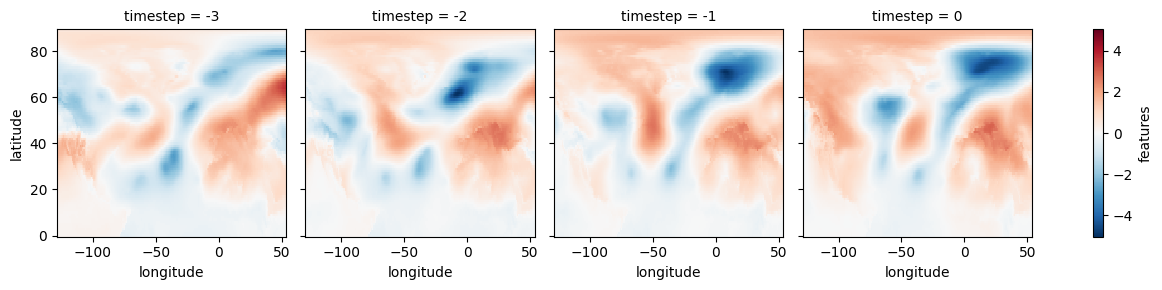

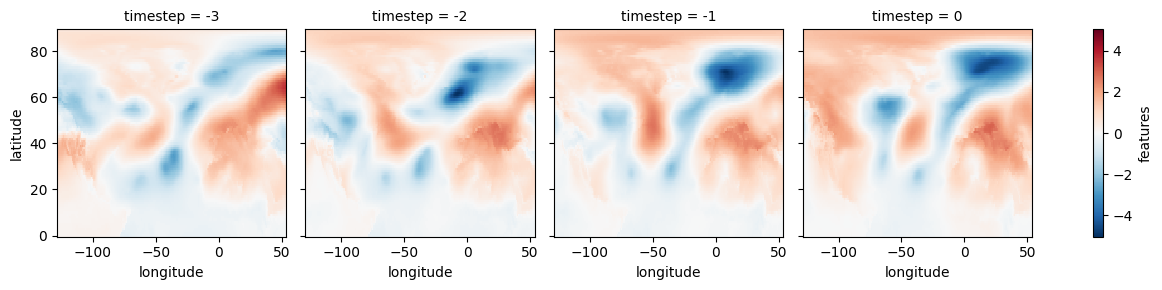

In [28]:
ds_attrs.features.sel(time=common_times).isel(time=1).plot(col='timestep')
ds_attrs_dropout.features.sel(time=common_times).isel(time=1).plot(col='timestep')

In [91]:
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/cmohe30c_attributions_TP.nc')
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_precip = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc')

ds_precip = ds_precip.where(ds_precip>1, drop=True)
ds_extr_pr = ds_precip.where(ds_precip>ds_precip.quantile(.9,'time'), drop=True)

df_features_extr = df_features.loc[ds_extr_pr.time.sel(time=slice('1999-10','2012-01')).values]
all_cyclones = df_features_extr.stack().where(df_features_extr.stack().str.startswith('C_')).dropna().str.split('_', expand=True).iloc[:,1]


all_cyclones = all_cyclones.loc[all_cyclones!='F'].reset_index()
# all_cyclones = all_cyclones.loc[all_cyclones.time.isin(ds_attrs.time.values)]
all_cyclones = all_cyclones.set_index('time')[1]
max_time = all_cyclones.reset_index().groupby([1]).time.max()
cyclogenesis = all_cyclones.reset_index().groupby([1]).time.min()
# all_cyclones

In [92]:
cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
cycs['day'] = cycs.date.dt.round('D')
cycs = cycs.loc[cycs.track_id.astype(str).isin(all_cyclones.values)]
cycs

new_cyc = []
cyclogen = []
for cyclone, time in zip(max_time.index, max_time.values):
    if cyclone=='F':
        continue
    new_cyc.append(cycs.query(f"track_id=={cyclone} & day<='{time}'").sort_values('date').iloc[-24:])
    cyclogen.append(cycs.query(f"track_id=={cyclone} & day<='{time}'").sort_values('date').iloc[[0]])
new_cyc = pd.concat(new_cyc)
cyclogen = pd.concat(cyclogen)

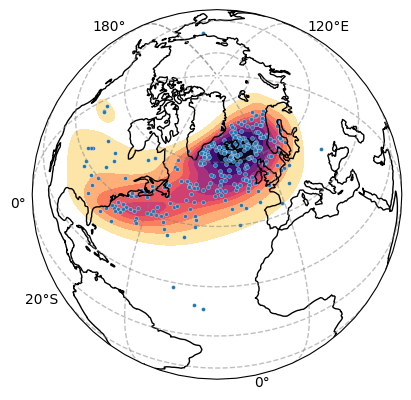

In [93]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.Orthographic(-30,50)))

sns.kdeplot(cyclogen, x='lon',y='lat', transform=ccrs.PlateCarree(), ax=ax, fill=True, cmap='magma_r')
sns.scatterplot(cyclogen, x='lon',y='lat', transform=ccrs.PlateCarree(), ax=ax, s=8, color='C0', )

ax.coastlines()
ax.set_global()

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

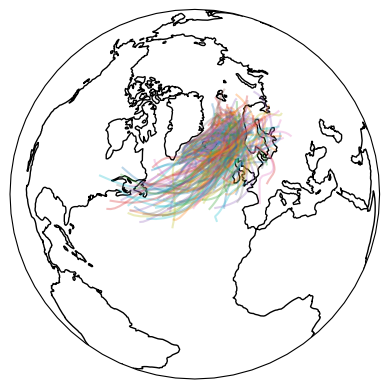

In [94]:

fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.Orthographic(-30,50)))
for cyc in new_cyc.track_id.unique():
    cyc_unique = new_cyc.query(f"track_id=={cyc}")
    ax.plot(cyc_unique.lon, cyc_unique.lat, transform=ccrs.PlateCarree(), alpha=.3)
ax.coastlines()
ax.set_global()

In [95]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')

In [96]:
df_feature_attrs = df_features_extr.loc[df_features_extr.index.isin(ds_attrs.time.values)]
all_ds_features = []
for time in tqdm(df_feature_attrs.index.round('D')[:]):
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone

    except:
        print(f"{time} failed on cyclones")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(time=time)
        all_ds_features.append(ds_features)
    
# ds_features_attrs = xr.concat(all_ds_features, dim='time', coords='minimal')
ds_features_attrs = xr.concat([d.expand_dims(time=1) for d in all_ds_features], dim='time').squeeze()


  0%|          | 0/28 [00:00<?, ?it/s]

Cyclone filtered out, maybe error
2000-02-28 00:00:00 failed on cyclones
2005-01-02 00:00:00 failed on cyclones
2006-12-14 00:00:00 failed on cyclones
2007-03-12 00:00:00 failed on cyclones
2007-03-13 00:00:00 failed on cyclones
2008-01-28 00:00:00 failed on cyclones
2008-01-29 00:00:00 failed on cyclones
2008-02-23 00:00:00 failed on cyclones
2008-02-24 00:00:00 failed on cyclones
2008-10-25 00:00:00 failed on cyclones
2009-09-27 00:00:00 failed on cyclones


In [97]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds = xr.Dataset(dict(attributions=attrs, distances=distances))
df_ = ds.to_dataframe().reset_index()
distance_bins= np.arange(0,10001,250)
summed_attrs = df_.groupby(['timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.sum().reset_index()
# df_ = attrs.groupby_bins(groups, bins).sum().to_series().reset_index()
# df_

/tmp/ipykernel_697547/89100493.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summed_attrs = df_.groupby(['timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.sum().reset_index()


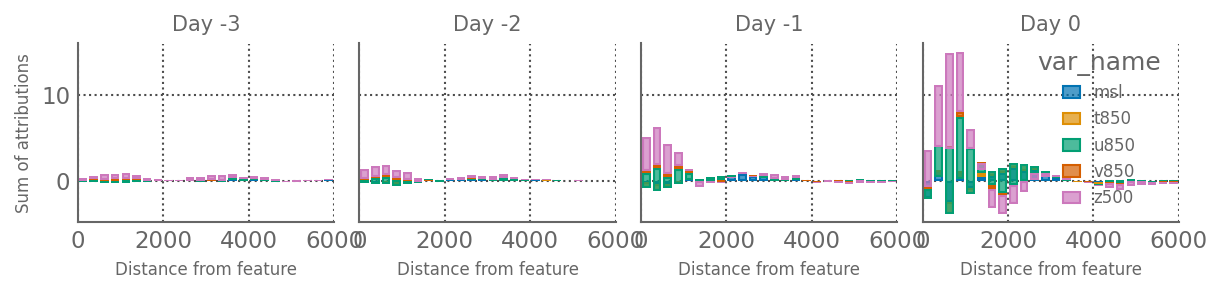

In [98]:
# summed_attrs = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,200))]).attributions.sum().reset_index()
summed_attrs['features_distance'] = [k.mid for k in summed_attrs.distances]
# summed_attrs
plot = (so.Plot(summed_attrs, x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(col='timestep',)
 .layout(size=(8,2))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,6000))
 .label(x='Distance from feature', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)

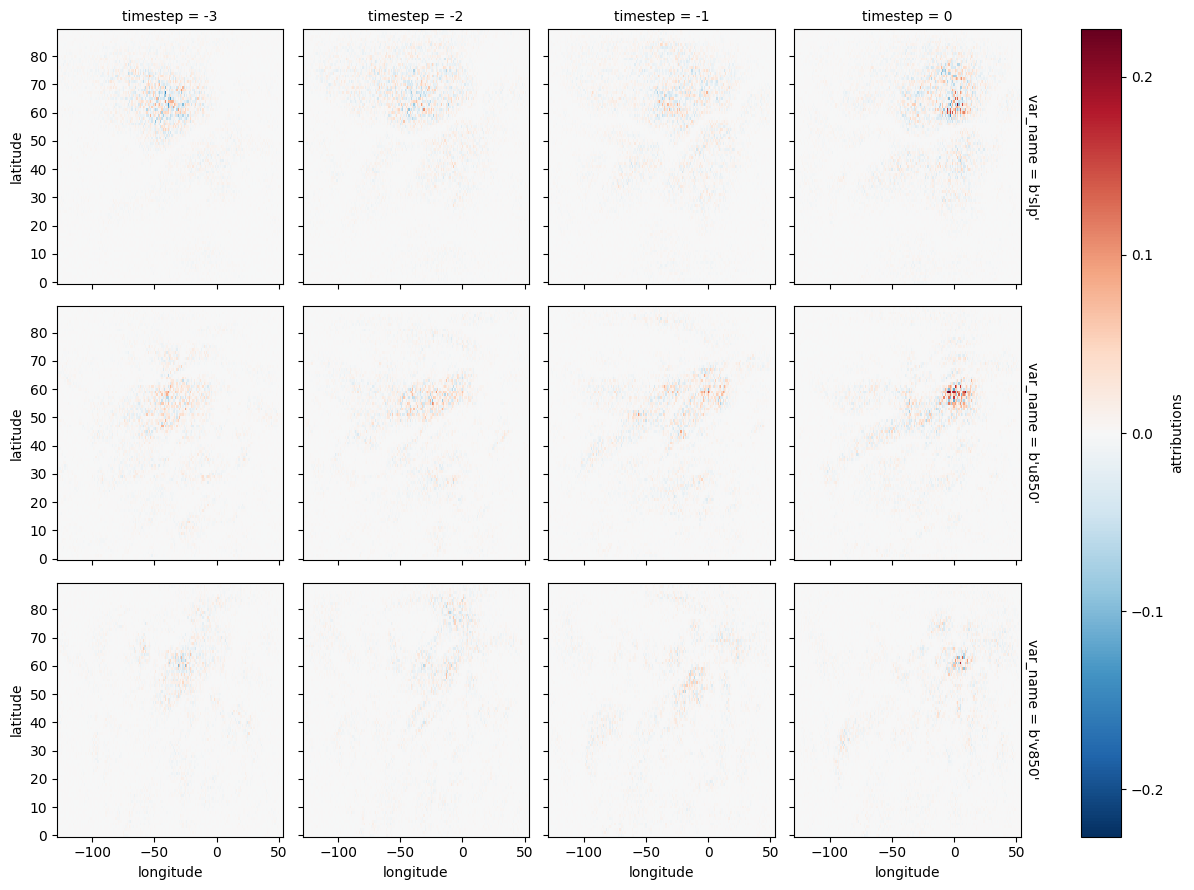

In [133]:
ds.attributions.isel(time=2).plot(col='timestep',row='var_name')